# Portfolio 2

Adapted from Multiple regression notebook authored by Jean-Gabriel Young <jean-gabriel.young@uvm.edu>

In [117]:
import pandas as pd
import numpy as np
import cmdstanpy
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt
import arviz as az
import os, cmdstanpy
cmdstanpy.set_cmdstan_path(os.path.expanduser("~/cmdstan"))



# Data construction and description
All units are in Montpelier. A single home is a unit. There are 1,509 in total, 100 of which are in the flood zone (blue dots) in figure below. A home counts as in the flood zone if any part of its footprint touches a FEMA Special Flood Hazard Area. We are particularly interested in the relationship between assessed home value, whether or not the home is in a flood zone, and the number of acres.

As we can see in the figure below, assessed value tends to increase with lot size, though with wide scatter. In-zone homes overlap heavily with out-of-zone homes, but they are concentrated on smaller lots, so a raw comparison between the two groups may partly reflect lot size.

In [140]:
montpelier_data = pd.read_csv("montpelier_parcels.csv")
filtered_montpelier_data = montpelier_data[montpelier_data['n_homes'] == 1]
filtered_montpelier_data = filtered_montpelier_data[filtered_montpelier_data['acres'] > 0]
filtered_montpelier_data = filtered_montpelier_data[filtered_montpelier_data['improvements_value'] > 0]

filtered_montpelier_data.head()

,object_id,category,listed_real_value,land_value,improvements_value,acres,n_homes,in_sfha,parcel_in_sfha
0,1184783,Residential I (Under 6 Acres),216500,67100,149400,0.15,1,0.0,0
1,1184784,Residential I (Under 6 Acres),476100,94900,381200,0.33,1,0.0,0
2,1184786,Residential I (Under 6 Acres),472400,135300,337100,0.40,1,0.0,0
7,1184792,Residential I (Under 6 Acres),230500,100600,129900,0.35,1,0.0,0
8,1184793,Residential I (Under 6 Acres),280000,71900,208100,0.07,1,0.0,0


In [141]:
filtered_montpelier_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1509 entries, 0 to 2126
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   object_id           1509 non-null   int64  
 1   category            1509 non-null   object 
 2   listed_real_value   1509 non-null   int64  
 3   land_value          1509 non-null   int64  
 4   improvements_value  1509 non-null   int64  
 5   acres               1509 non-null   float64
 6   n_homes             1509 non-null   int64  
 7   in_sfha             1509 non-null   float64
 8   parcel_in_sfha      1509 non-null   int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 117.9+ KB


In [ ]:
print(f"Mean house value: {filtered_montpelier_data['listed_real_value'].mean()}")
print(f"Mean in flood zone: {filtered_montpelier_data[filtered_montpelier_data['in_sfha'] == 1]['listed_real_value'].mean()}")
print(f"Mean out of flood zone: {filtered_montpelier_data[filtered_montpelier_data['in_sfha'] == 0]['listed_real_value'].mean()}")


Mean house value: 368476.0768721007
Mean in flood zone: 349221.0
Mean out of flood zone: 369842.65436479775


In [120]:
def viz_scatter(x_col, y_col, xlabel, ylabel, x_ticks=None, y_ticks=None, title=None):
    out_zone = filtered_montpelier_data[filtered_montpelier_data['in_sfha'] == 0]
    in_zone = filtered_montpelier_data[filtered_montpelier_data['in_sfha'] == 1]

    plt.figure(figsize=(7, 6))
    plt.scatter(out_zone[x_col], out_zone[y_col], color='lightgrey', edgecolors='k',
                linewidths=0.5, alpha=0.6,                                  # NEW: transparency
                label=f'Outside SFHA (n = {len(out_zone):,})')              # NEW: counts
    plt.scatter(in_zone[x_col], in_zone[y_col], color='tab:blue', edgecolors='k',
                linewidths=0.5,
                label=f'Inside SFHA (n = {len(in_zone):,})')                # NEW: counts
    plt.xlabel(xlabel, fontsize=13)                                         # NEW: font size
    plt.ylabel(ylabel, fontsize=13)
    plt.legend(title='Flood zone', fontsize=11, title_fontsize=11, loc='lower right')
    if title is not None:                                                   # NEW: title
        plt.title(title, fontsize=14)

    if x_ticks is not None:
        values, labels = x_ticks
        plt.xticks(np.log(values), labels)
    if y_ticks is not None:
        values, labels = y_ticks
        plt.yticks(np.log(values), labels)
    plt.tick_params(labelsize=11)                                           # NEW: tick font size

    ax = plt.gca()                                                          # NEW: remove top/right borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

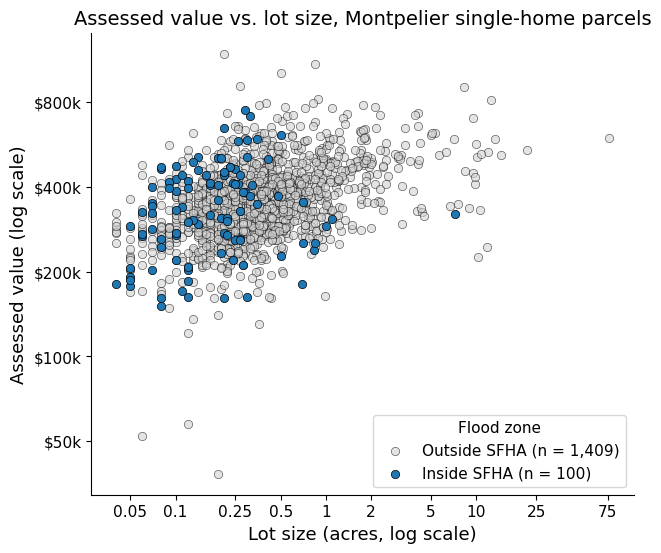

In [121]:
filtered_montpelier_data['log_acres'] = np.log(filtered_montpelier_data['acres'])
filtered_montpelier_data['log_value'] = np.log(filtered_montpelier_data['listed_real_value'])

acre_ticks = ([0.05, 0.1, 0.25, 0.5, 1, 2, 5, 10, 25, 75],
              ['0.05', '0.1', '0.25', '0.5', '1', '2', '5', '10', '25', '75'])
dollar_ticks = ([50_000, 100_000, 200_000, 400_000, 800_000],
                ['$50k', '$100k', '$200k', '$400k', '$800k'])

viz_scatter('log_acres', 'log_value',
            'Lot size (acres, log scale)', 'Assessed value (log scale)',
            x_ticks=acre_ticks, y_ticks=dollar_ticks,
            title='Assessed value vs. lot size, Montpelier single-home parcels')

In [122]:
filtered_montpelier_data.groupby('in_sfha')['log_value'].agg(['count', 'mean', 'std'])


,count,mean,std
in_sfha,,,
0.0,1409,12.773544,0.310030
1.0,100,12.695525,0.375086


# Modeling question: Are homes in Montpelier's FEMA flood zone area assessed differently from homes outside it, on lots of the same size, and by how much?
We are interested in the assessed home value as an outcome, and flood zone status and number of acres as predictors. 

In [123]:
X = filtered_montpelier_data['in_sfha']
Y = filtered_montpelier_data["log_value"]
N = len(Y)

simple_data = {'N': N, 'X': X, 'Y': Y, 'use_likelihood': 1}


# Model description
For readability and interpretability, we model in log scale. As in JG's example, we will motivate a multiple regression with a simple regression.

$$Y_i\sim\mathrm{Normal}(\mu_i,\sigma)$$
$$\mu_i = \alpha + \beta X_i$$
$$\alpha\sim \mathrm{Normal}(12, 0.5)$$
$$\beta \sim\mathrm{Normal}(0,0.5)$$
$$\sigma \sim\mathrm{Exponential}(3)$$

In [124]:
model = CmdStanModel(stan_file="stan_code/simple_regression.stan")
simple_fit = model.sample(data=simple_data, chains=2, seed=6300)

12:44:25 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

12:44:27 - cmdstanpy - INFO - CmdStan done processing.
12:44:27 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'simple_regression.stan', line 29, column 8 to column 30)
Consider re-running with show_console=True if the above output is unclear!


In [125]:
simple_fit.summary().loc[['alpha', 'beta', 'sigma']]


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
alpha,12.773300,0.000213,0.008505,0.008492,12.760000,12.773300,12.787500,1609.56,1440.23,503.143,1.00157
beta,-0.078162,0.000753,0.031903,0.032336,-0.130508,-0.078298,-0.026278,1787.72,1366.76,558.836,0.99991
sigma,0.315011,0.000142,0.005945,0.006081,0.305367,0.314938,0.324666,1795.96,1319.78,561.412,1.00158


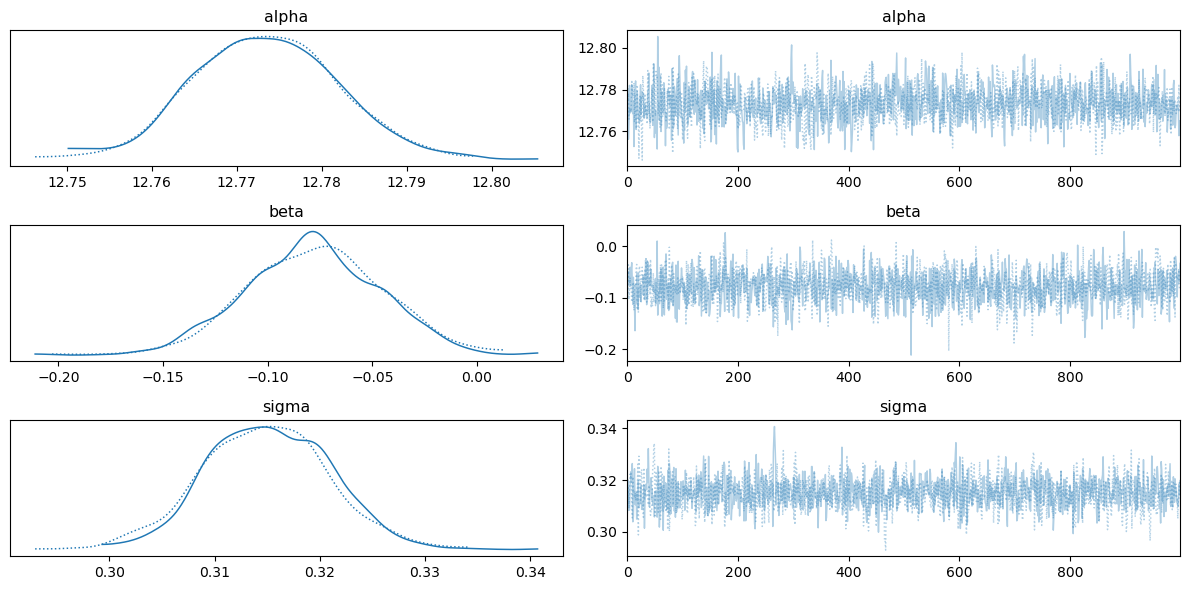

In [126]:
fit_simple_az = az.from_cmdstanpy(posterior=simple_fit)
az.plot_trace(fit_simple_az, var_names=['alpha', 'beta', 'sigma']);
plt.tight_layout()

In [127]:
prior_data = {**simple_data, 'use_likelihood': 0}   # same data, likelihood off
prior_fit = model.sample(data=prior_data, chains=2, seed=6300)

Y_prior = prior_fit.stan_variable('Y_rep')    # shape: (2000 draws, 1509 houses), log scale
prior_dollars = np.exp(Y_prior)               # back to dollars

pcts = [2.5, 25, 50, 75, 97.5]
print("Prior predictive ($):", np.percentile(prior_dollars, pcts).round(-3))
print("Observed ($):        ", np.percentile(filtered_montpelier_data['listed_real_value'], pcts).round(-3))

12:44:37 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

12:44:39 - cmdstanpy - INFO - CmdStan done processing.



Prior predictive ($): [ 41000. 111000. 168000. 249000. 614000.]
Observed ($):         [190000. 288000. 347000. 425000. 651000.]


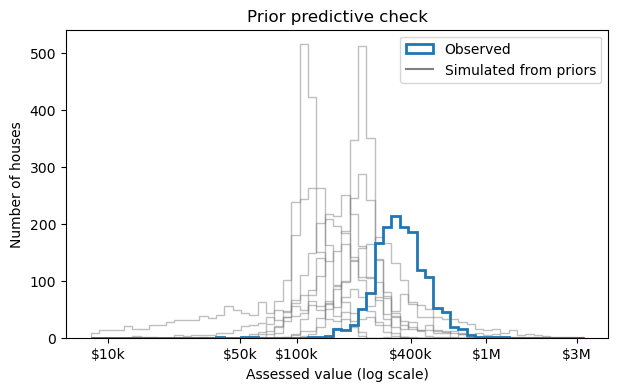

In [128]:
plt.figure(figsize=(7, 4))
bins = np.linspace(9, 15, 60)   # log-value range: about $8k to $3.3M

for s in np.random.choice(len(Y_prior), 10, replace=False):
    plt.hist(Y_prior[s], bins=bins, histtype='step', color='grey', alpha=0.5)
plt.hist(filtered_montpelier_data['log_value'], bins=bins, histtype='step',
         color='tab:blue', linewidth=2, label='Observed')

plt.plot([], [], color='grey', label='Simulated from priors')   # legend entry for grey lines
plt.xticks(np.log([10_000, 50_000, 100_000, 400_000, 1_000_000, 3_000_000]),
           ['$10k', '$50k', '$100k', '$400k', '$1M', '$3M'])
plt.xlabel('Assessed value (log scale)')
plt.ylabel('Number of houses')
plt.title('Prior predictive check')
plt.legend()

Observed min: $38,300
Share of simulated towns with a min that low: 0.000
Observed in-zone sd: 0.373
Share of simulated towns with in-zone sd that large: 0.006


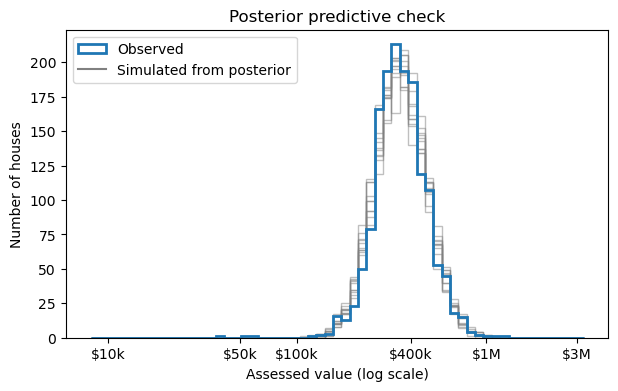

In [129]:
Y_post = simple_fit.stan_variable('Y_rep')   # posterior predictive, log scale

plt.figure(figsize=(7, 4))
bins = np.linspace(9, 15, 60)

for s in np.random.choice(len(Y_post), 10, replace=False):
    plt.hist(Y_post[s], bins=bins, histtype='step', color='grey', alpha=0.5)
plt.hist(filtered_montpelier_data['log_value'], bins=bins, histtype='step',
         color='tab:blue', linewidth=2, label='Observed')

plt.plot([], [], color='grey', label='Simulated from posterior')
plt.xticks(np.log([10_000, 50_000, 100_000, 400_000, 1_000_000, 3_000_000]),
           ['$10k', '$50k', '$100k', '$400k', '$1M', '$3M'])
plt.xlabel('Assessed value (log scale)')
plt.ylabel('Number of houses')
plt.title('Posterior predictive check')
plt.legend()

obs = filtered_montpelier_data['log_value'].values
in_zone = filtered_montpelier_data['in_sfha'].values == 1

# 1. Cheapest house: can the model produce values as low as the real minimum?
sim_min = Y_post.min(axis=1)
print(f"Observed min: ${np.exp(obs.min()):,.0f}")
print(f"Share of simulated towns with a min that low: {(sim_min <= obs.min()).mean():.3f}")

# 2. Spread within the flood zone: does one shared sigma fit the in-zone group?
sim_sd_in = Y_post[:, in_zone].std(axis=1)
print(f"Observed in-zone sd: {obs[in_zone].std():.3f}")
print(f"Share of simulated towns with in-zone sd that large: {(sim_sd_in >= obs[in_zone].std()).mean():.3f}")

# Multiple Regression
We update our model to

$$Y_i\sim\mathrm{Normal}(\mu_i,\sigma)$$
$$\mu_i = \alpha + \beta_1 X_{i1} + \beta_2 X_{i2}$$
$$\alpha\sim \mathrm{Normal}(12, 0.5)$$
$$\beta_j \sim\mathrm{Normal}(0,0.5)$$
$$\sigma \sim\mathrm{Exponential}(3)$$

In [130]:
X = np.array(filtered_montpelier_data[['in_sfha', 'log_acres']])  
X[:5]

array([[ 0.        , -1.89711998],
       [ 0.        , -1.10866262],
       [ 0.        , -0.91629073],
       [ 0.        , -1.04982212],
       [ 0.        , -2.65926004]])

In [131]:
multiple_data = {'N': N, 'q': X.shape[1], 'X': X, 'Y': Y, 'use_likelihood': 1}  # 0: prior; 1: posterior
multiple_model = CmdStanModel(stan_file="stan_code/multiple_regression.stan")

multiple_fit = multiple_model.sample(data=multiple_data, chains=2, seed=6300)

12:44:42 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

12:44:45 - cmdstanpy - INFO - CmdStan done processing.


In [132]:
multiple_fit.summary().loc[['alpha', 'beta[1]', 'beta[2]', 'sigma']]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
alpha,12.914200,0.000302,0.010854,0.010748,12.896300,12.914100,12.931600,1290.17,1451.67,276.800,1.000890
beta[1],0.026536,0.000740,0.029650,0.029922,-0.020661,0.026341,0.074105,1627.21,1290.48,349.113,1.002130
beta[2],0.141119,0.000205,0.007536,0.007565,0.128863,0.141209,0.153366,1362.54,1271.19,292.329,1.001900
sigma,0.285127,0.000117,0.005225,0.005148,0.276701,0.284960,0.294248,1984.60,1334.02,425.789,0.999885


In [133]:
alpha_multiple = multiple_fit.stan_variable('alpha')
beta_multiple = multiple_fit.stan_variable('beta')
sigma_multiple = multiple_fit.stan_variable('sigma')
mu_multiple = multiple_fit.stan_variable('mu')

alpha_simple = simple_fit.stan_variable('alpha')
beta_simple = simple_fit.stan_variable('beta')
sigma_simple = simple_fit.stan_variable('sigma')
mu_simple = simple_fit.stan_variable('mu')

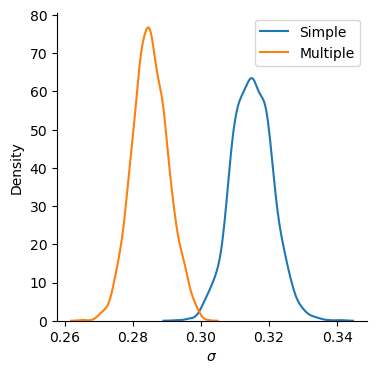

In [134]:
import seaborn as sns
plt.figure(figsize=(4, 4))
sns.kdeplot(sigma_simple, label='Simple')
sns.kdeplot(sigma_multiple, label='Multiple')
plt.xlabel(r'$\sigma$')
plt.ylabel('Density')
sns.despine()
plt.legend()

In [135]:
multiple_prior_data = {'N': N, 'q': X.shape[1], 'X': X, 'Y': Y, 'use_likelihood': 0}  # 0: prior; 1: posterior
multiple_prior_fit = multiple_model.sample(data=multiple_prior_data, chains=2, seed=6300)

Y_prior_multiple = multiple_prior_fit.stan_variable('Y_rep')    # shape: (2000 draws, 1509 houses), log scale
prior_dollars = np.exp(Y_prior_multiple)               # back to dollars

pcts = [2.5, 25, 50, 75, 97.5]
print("Prior predictive ($):", np.percentile(prior_dollars, pcts).round(-3))
print("Observed ($):        ", np.percentile(filtered_montpelier_data['listed_real_value'], pcts).round(-3))

12:44:55 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

12:44:58 - cmdstanpy - INFO - CmdStan done processing.



Prior predictive ($): [  22000.   90000.  164000.  294000. 1158000.]
Observed ($):         [190000. 288000. 347000. 425000. 651000.]


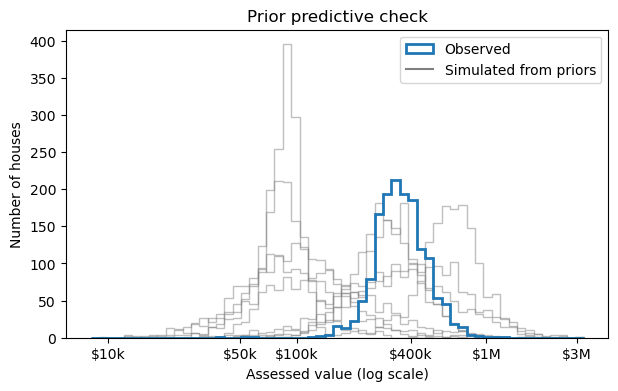

In [136]:
plt.figure(figsize=(7, 4))
bins = np.linspace(9, 15, 60)   # log-value range: about $8k to $3.3M

for s in np.random.choice(len(Y_prior_multiple), 10, replace=False):
    plt.hist(Y_prior_multiple[s], bins=bins, histtype='step', color='grey', alpha=0.5)
plt.hist(filtered_montpelier_data['log_value'], bins=bins, histtype='step',
         color='tab:blue', linewidth=2, label='Observed')

plt.plot([], [], color='grey', label='Simulated from priors')   # legend entry for grey lines
plt.xticks(np.log([10_000, 50_000, 100_000, 400_000, 1_000_000, 3_000_000]),
           ['$10k', '$50k', '$100k', '$400k', '$1M', '$3M'])
plt.xlabel('Assessed value (log scale)')
plt.ylabel('Number of houses')
plt.title('Prior predictive check')
plt.legend()

Observed min: $38,300
Share of simulated towns with a min that low: 0.000
Observed in-zone sd: 0.373
Share of simulated towns with in-zone sd that large: 0.004


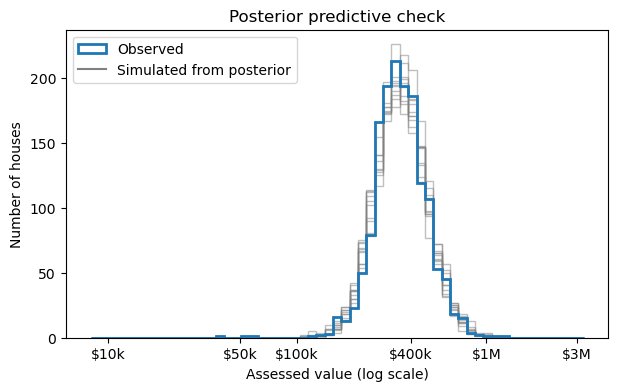

In [137]:
Y_post = multiple_fit.stan_variable('Y_rep')   # posterior predictive, log scale

plt.figure(figsize=(7, 4))
bins = np.linspace(9, 15, 60)

for s in np.random.choice(len(Y_post), 10, replace=False):
    plt.hist(Y_post[s], bins=bins, histtype='step', color='grey', alpha=0.5)
plt.hist(filtered_montpelier_data['log_value'], bins=bins, histtype='step',
         color='tab:blue', linewidth=2, label='Observed')

plt.plot([], [], color='grey', label='Simulated from posterior')
plt.xticks(np.log([10_000, 50_000, 100_000, 400_000, 1_000_000, 3_000_000]),
           ['$10k', '$50k', '$100k', '$400k', '$1M', '$3M'])
plt.xlabel('Assessed value (log scale)')
plt.ylabel('Number of houses')
plt.title('Posterior predictive check')
plt.legend()

obs = filtered_montpelier_data['log_value'].values
in_zone = filtered_montpelier_data['in_sfha'].values == 1

# 1. Cheapest house: can the model produce values as low as the real minimum?
sim_min = Y_post.min(axis=1)
print(f"Observed min: ${np.exp(obs.min()):,.0f}")
print(f"Share of simulated towns with a min that low: {(sim_min <= obs.min()).mean():.3f}")

# 2. Spread within the flood zone: does one shared sigma fit the in-zone group?
sim_sd_in = Y_post[:, in_zone].std(axis=1)
print(f"Observed in-zone sd: {obs[in_zone].std():.3f}")
print(f"Share of simulated towns with in-zone sd that large: {(sim_sd_in >= obs[in_zone].std()).mean():.3f}")